In [1]:
import os, sys, glob, re, random, math, time
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

import scanpy as sc
import scanpy.external as sce
import anndata
from harmony import harmonize
import symphonypy as sp
import infercnvpy as cnv
import decoupler as dc
import celltypist
from celltypist import models
import scvelo as scv
import cellrank as cr
import scvi
import scarches as sca
from scib_metrics.benchmark import Benchmarker
# import cell2location
# import squidpy as sq
# import SEACells
# import pertpy
import milopy
import milopy.core as milo
import milopy.plot as milopl

import sceleto2 as scjp
sys.path.append('/home/yongjunkoh/packages/python-genomics/')
import Scanpyplus

from platform import python_version 
print('Python ', python_version(), end='\n')
sc.logging.print_version_and_date()
sc.logging.print_header()
# sc.logging.print_versions(file=None)
sc.settings.verbosity = 3 # errors (0), warnings (1), info (2), hints (3)
scv.settings.verbosity = 3 # errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=100, figsize=(4, 4), color_map='OrRd', frameon=False)

# plt.rcParams['figure.figsize'] = [4, 4]
# plt.rcParams['figure.dpi'] = 80
# plt.rcParams["savefig.dpi"] = 150

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'

/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.4.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
 captum (see https://github.com/pytorch/captum).
INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /home/yongjunkoh/.conda/envs/rpy2/lib/R
INFO:rpy2.situat

Python  3.9.18
Running Scanpy 1.9.6, on 2024-08-05 15:31.
scanpy==1.9.6 anndata==0.9.2 umap==0.5.4 numpy==1.24.4 scipy==1.9.1 pandas==1.5.3 scikit-learn==1.3.2 statsmodels==0.14.0 igraph==0.10.8 pynndescent==0.5.10


In [2]:
adata = sc.read('write/salivary-fig_240421_3cond.h5ad')

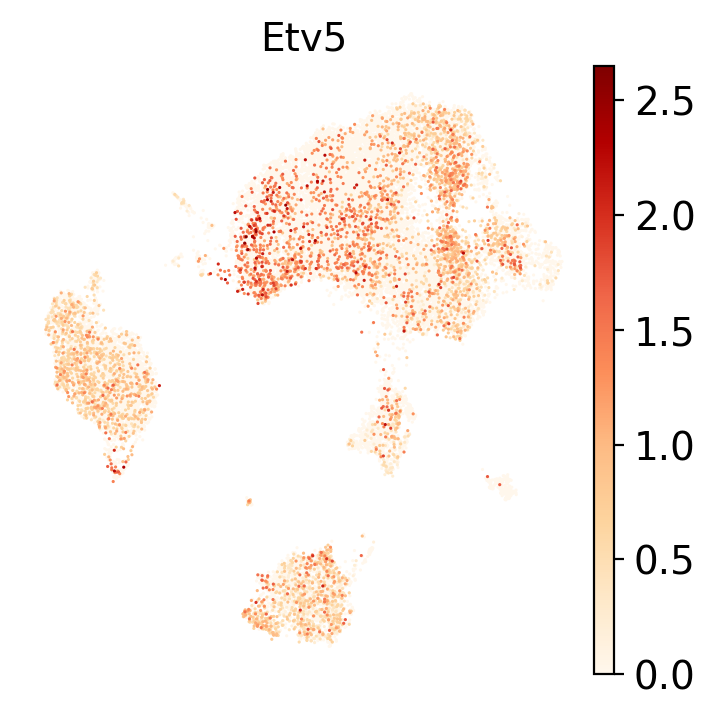

In [3]:
sc.pl.umap(adata, color=['Etv5'])

/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


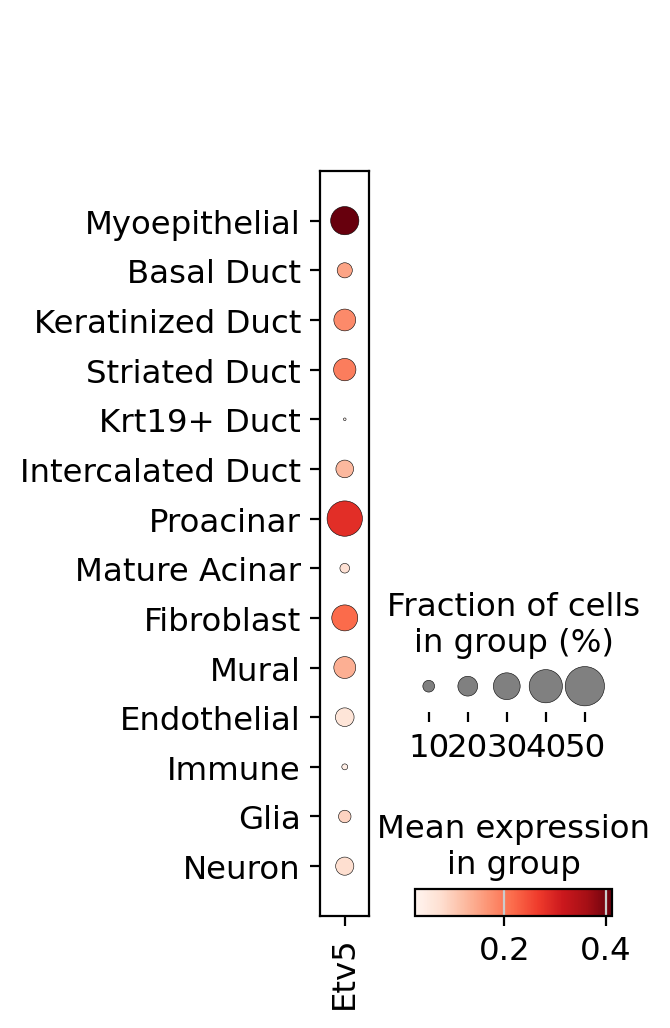

In [5]:
sc.pl.dotplot(adata, ['Etv5'], groupby='cell_type_v1')

/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


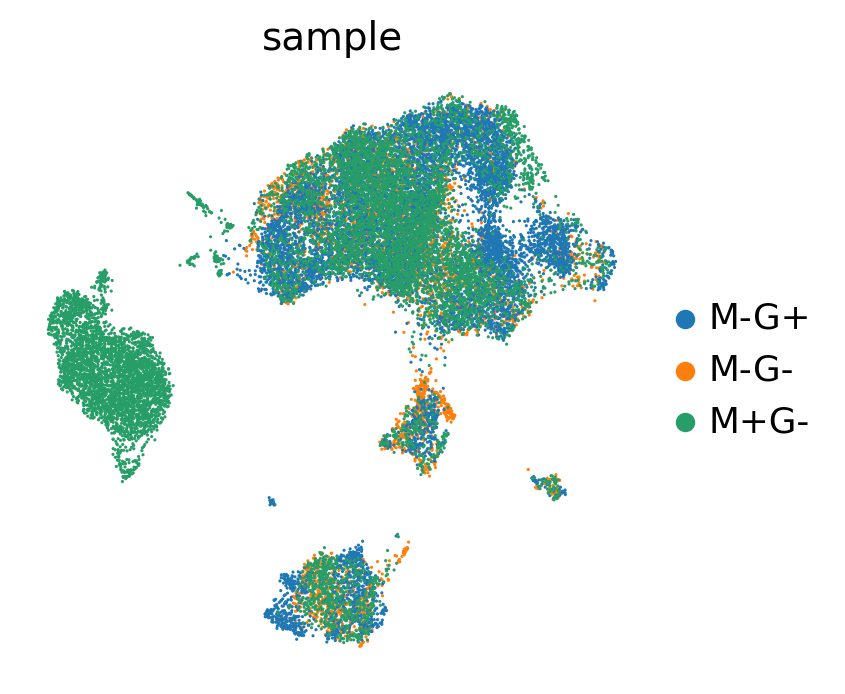

In [5]:
sc.pl.umap(adata, color=['sample'])

In [6]:
bdata = adata.copy()
adata = bdata.raw.to_adata()
adata.layers = bdata.layers
adata = adata[adata.obs['sample'].isin(['M+G-'])]
adata.raw = adata

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    subset=False,
    layer="counts",
    flavor="seurat_v3",
    # batch_key="sample"
)


adata.var['highly_variable_beforecc'] = adata.var['highly_variable'] 
cell_cycle_genes = [x.strip().capitalize()
                    for x in open('/home/yongjunkoh/references/regev_lab_cell_cycle_genes.txt')]
adata.var['highly_variable'] = [False if x in cell_cycle_genes else y for (x, y) in zip(adata.var.index, adata.var['highly_variable'])]

sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=50, use_rep='X_pca')
# sce.pp.harmony_integrate(adata, 'sample', max_iter_harmony=50)
# sc.pp.neighbors(adata, n_pcs=50, use_rep='X_pca_harmony')
sc.tl.umap(adata)

cell_cycle_genes = [x.strip().capitalize()
                    for x in open('/home/yongjunkoh/references/regev_lab_cell_cycle_genes.txt')]
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]
sc.tl.score_genes_cell_cycle(adata, s_genes, g2m_genes)

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:01)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:24)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:12)
calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    342 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    387 total control genes are used. (0:0

... storing 'phase' as categorical
/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


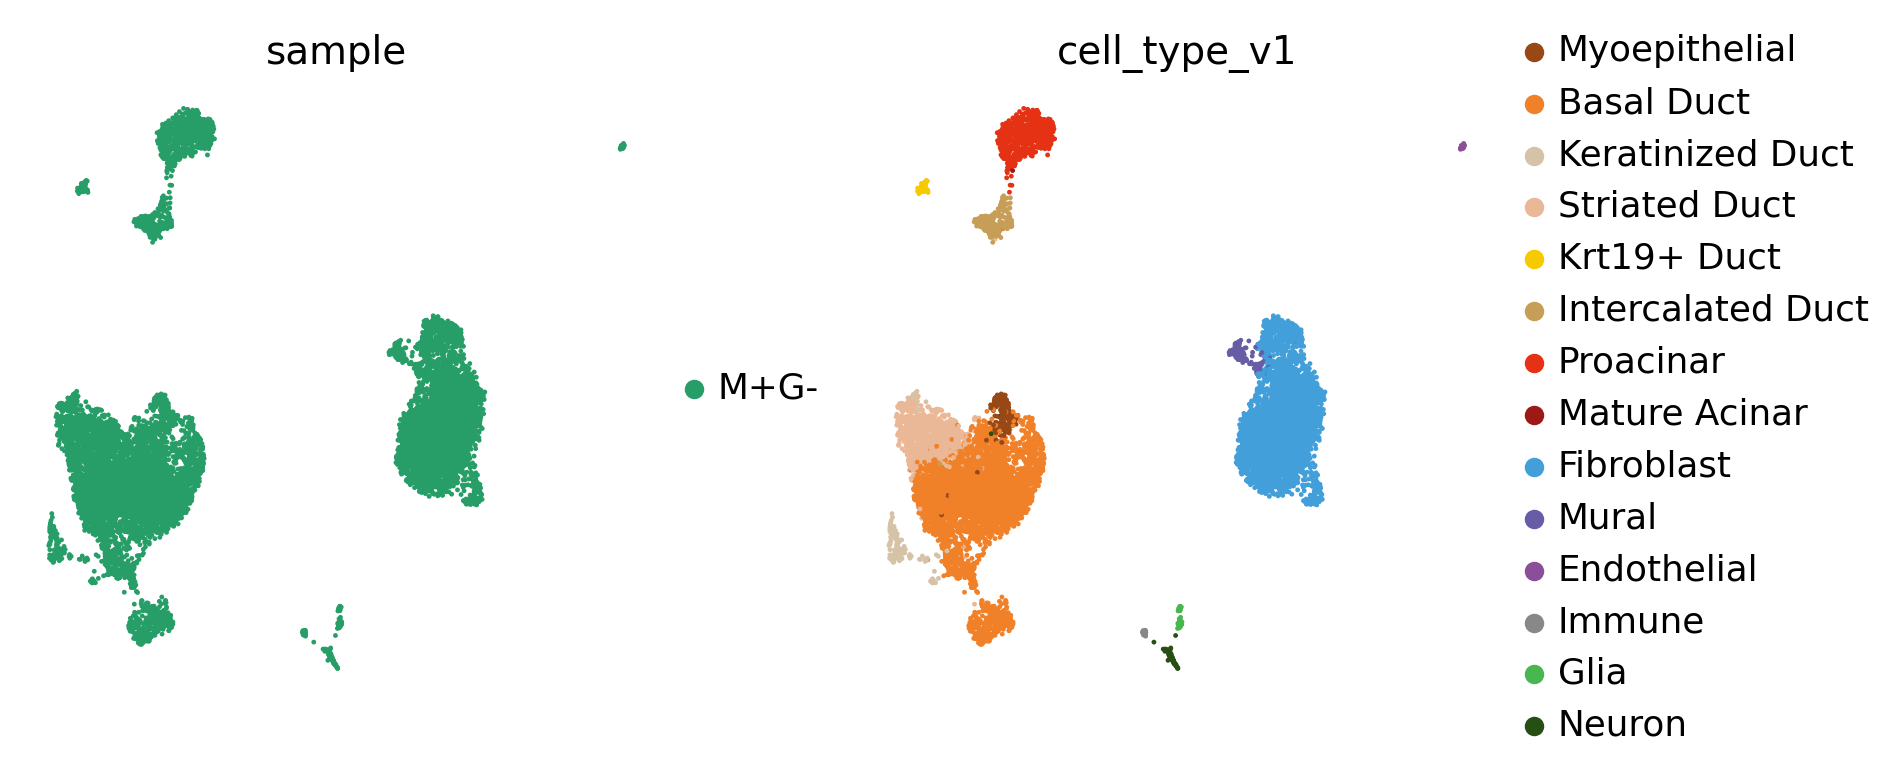

In [7]:
sc.pl.umap(adata, color=['sample', 'cell_type_v1'])

In [8]:
adata.obs['cell_type_v1'].cat.categories

Index(['Myoepithelial', 'Basal Duct', 'Keratinized Duct', 'Striated Duct',
       'Krt19+ Duct', 'Intercalated Duct', 'Proacinar', 'Mature Acinar',
       'Fibroblast', 'Mural', 'Endothelial', 'Immune', 'Glia', 'Neuron'],
      dtype='object')

In [9]:
stromalL = ['Fibroblast', 'Mural', 'Endothelial', 'Immune', 'Glia', 'Neuron']

/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


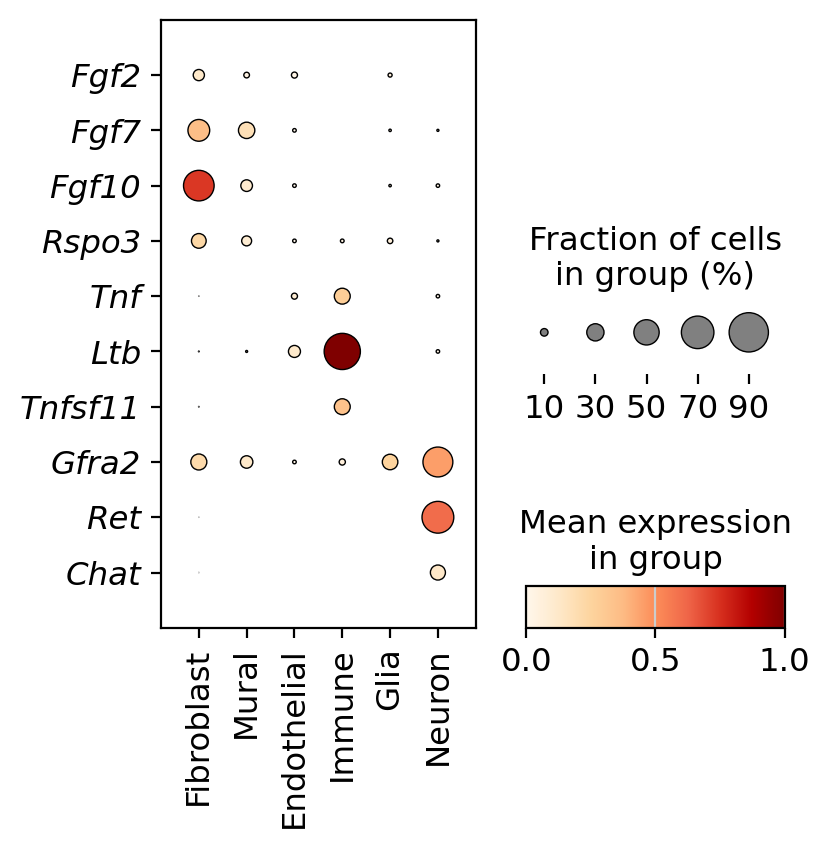

In [64]:
sc.settings.set_figure_params(dpi=100, figsize=(4, 4), color_map='OrRd', frameon=False)

dp = sc.pl.dotplot(adata[adata.obs['cell_type_v1'].isin(stromalL)], 
                  ['Fgf2', 'Fgf7', 'Fgf10', 
                   'Rspo3',
                   'Tnf', 'Ltb', 'Tnfsf11', 
                   'Gfra2', 'Ret',
                   'Chat'], 
                  groupby='cell_type_v1', 
                  swap_axes=True,
                  vmax=1,
                  figsize=(4,4),
                  return_fig=True)

dp = dp.swap_axes().legend(width=1.8).style(cmap='OrRd', dot_edge_color='black', dot_edge_lw=0.5).get_axes()

ax=dp['mainplot_ax']
# Loop through ticklabels and make them italic
for l in ax.get_yticklabels():
    l.set_style('italic')
    # g=l.get_text()
    # # Change settings (e.g. color) of certain ticklabels based on their text (here gene name)
    # if g == 'Acta2':
    #     l.set_color('#A97F03')
    # if g in ['Krt5', 'Krt7', 'Krt19', 'Gstt1']:
    #     l.set_color('#A97F03')
    # if g in ['Smgc', 'Bpifa2', 'Aqp5', 'Lpo', 'Bhlha15']:
    #     l.set_color('#A97F03')
        
# ax.figure.savefig('figures/figS1-dotplot-stage.pdf', bbox_inches='tight')

sc.settings.set_figure_params(dpi=100, figsize=(4, 4), color_map='OrRd', frameon=False)

/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


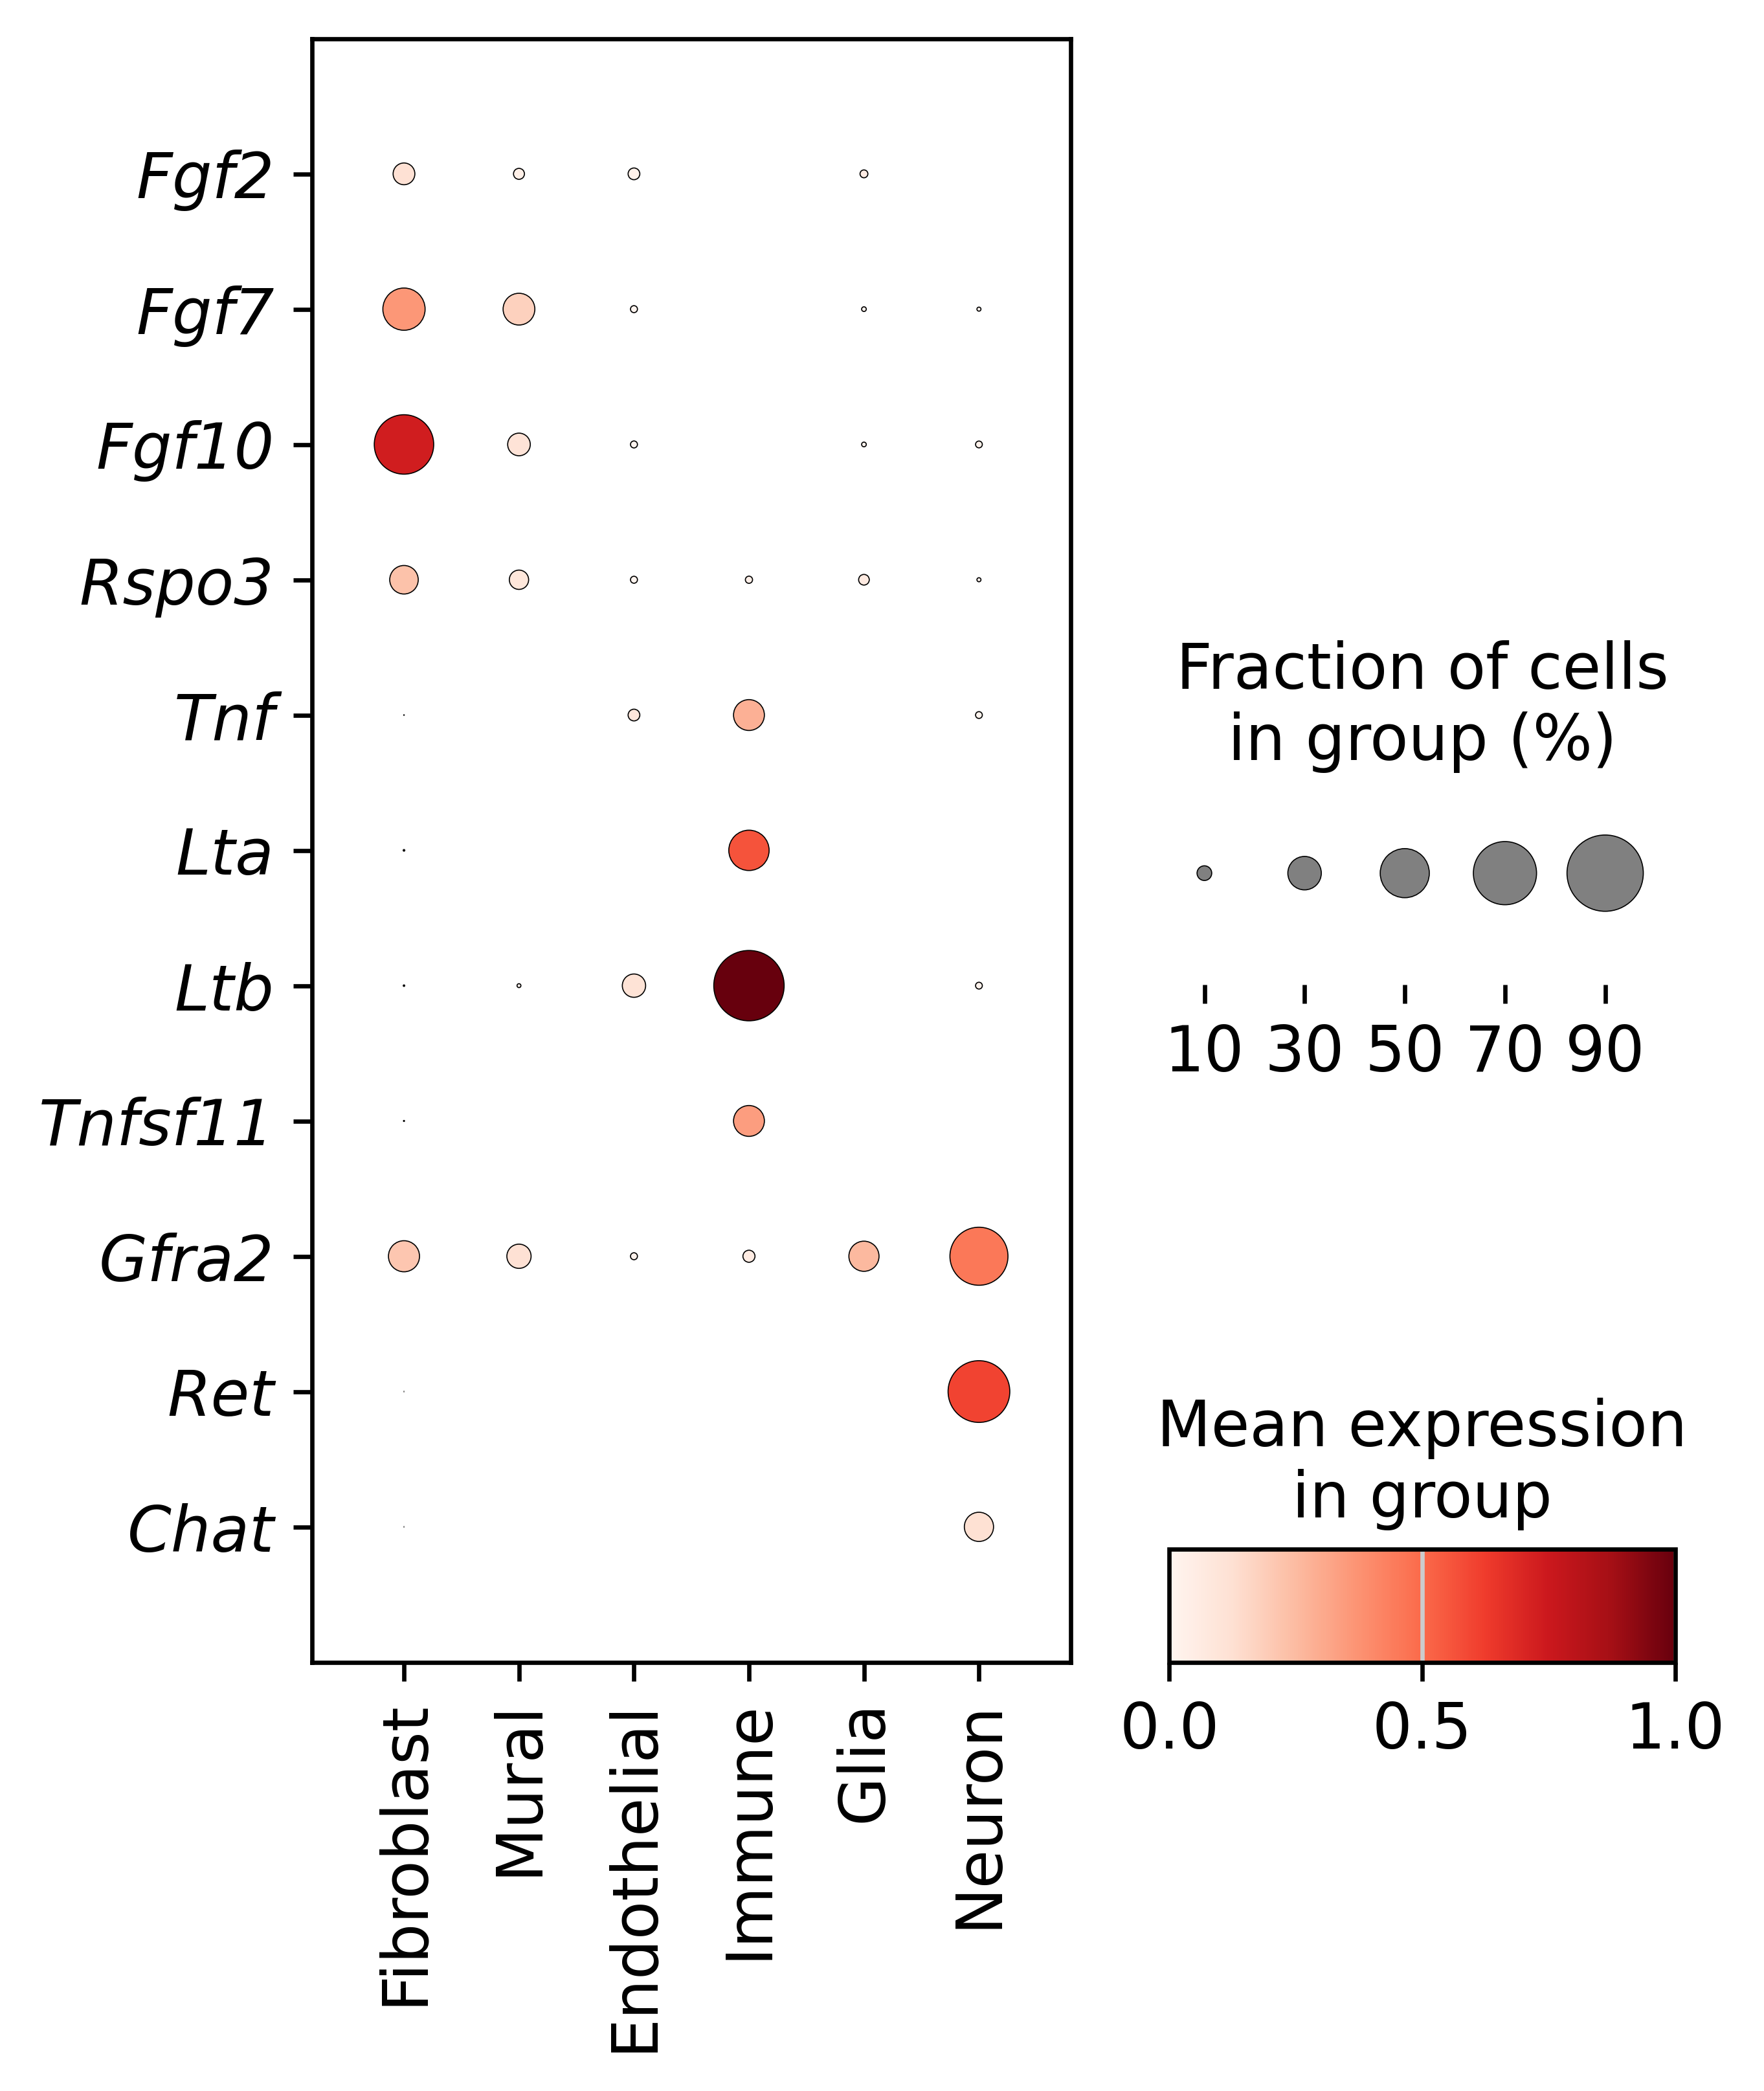

In [71]:
sc.settings.set_figure_params(dpi=300, figsize=(4, 4), color_map='OrRd', frameon=False)

dp = sc.pl.dotplot(adata[adata.obs['cell_type_v1'].isin(stromalL)], 
                  ['Fgf2', 'Fgf7', 'Fgf10', 
                   'Rspo3',
                   'Tnf', 'Lta', 'Ltb', 'Tnfsf11', 
                   'Gfra2', 'Ret',
                   'Chat'], 
                  groupby='cell_type_v1', 
                  swap_axes=True,
                  vmax=1,
                  figsize=(4.5,11/2),
                  return_fig=True)

dp = dp.swap_axes().legend(width=1.8).get_axes()

ax=dp['mainplot_ax']
# Loop through ticklabels and make them italic
for l in ax.get_yticklabels():
    l.set_style('italic')
    # g=l.get_text()
    # # Change settings (e.g. color) of certain ticklabels based on their text (here gene name)
    # if g == 'Acta2':
    #     l.set_color('#A97F03')
    # if g in ['Krt5', 'Krt7', 'Krt19', 'Gstt1']:
    #     l.set_color('#A97F03')
    # if g in ['Smgc', 'Bpifa2', 'Aqp5', 'Lpo', 'Bhlha15']:
    #     l.set_color('#A97F03')
        
# ax.figure.savefig('figures/figS1-dotplot-stage.pdf', bbox_inches='tight')

sc.settings.set_figure_params(dpi=100, figsize=(4, 4), color_map='OrRd', frameon=False)

/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


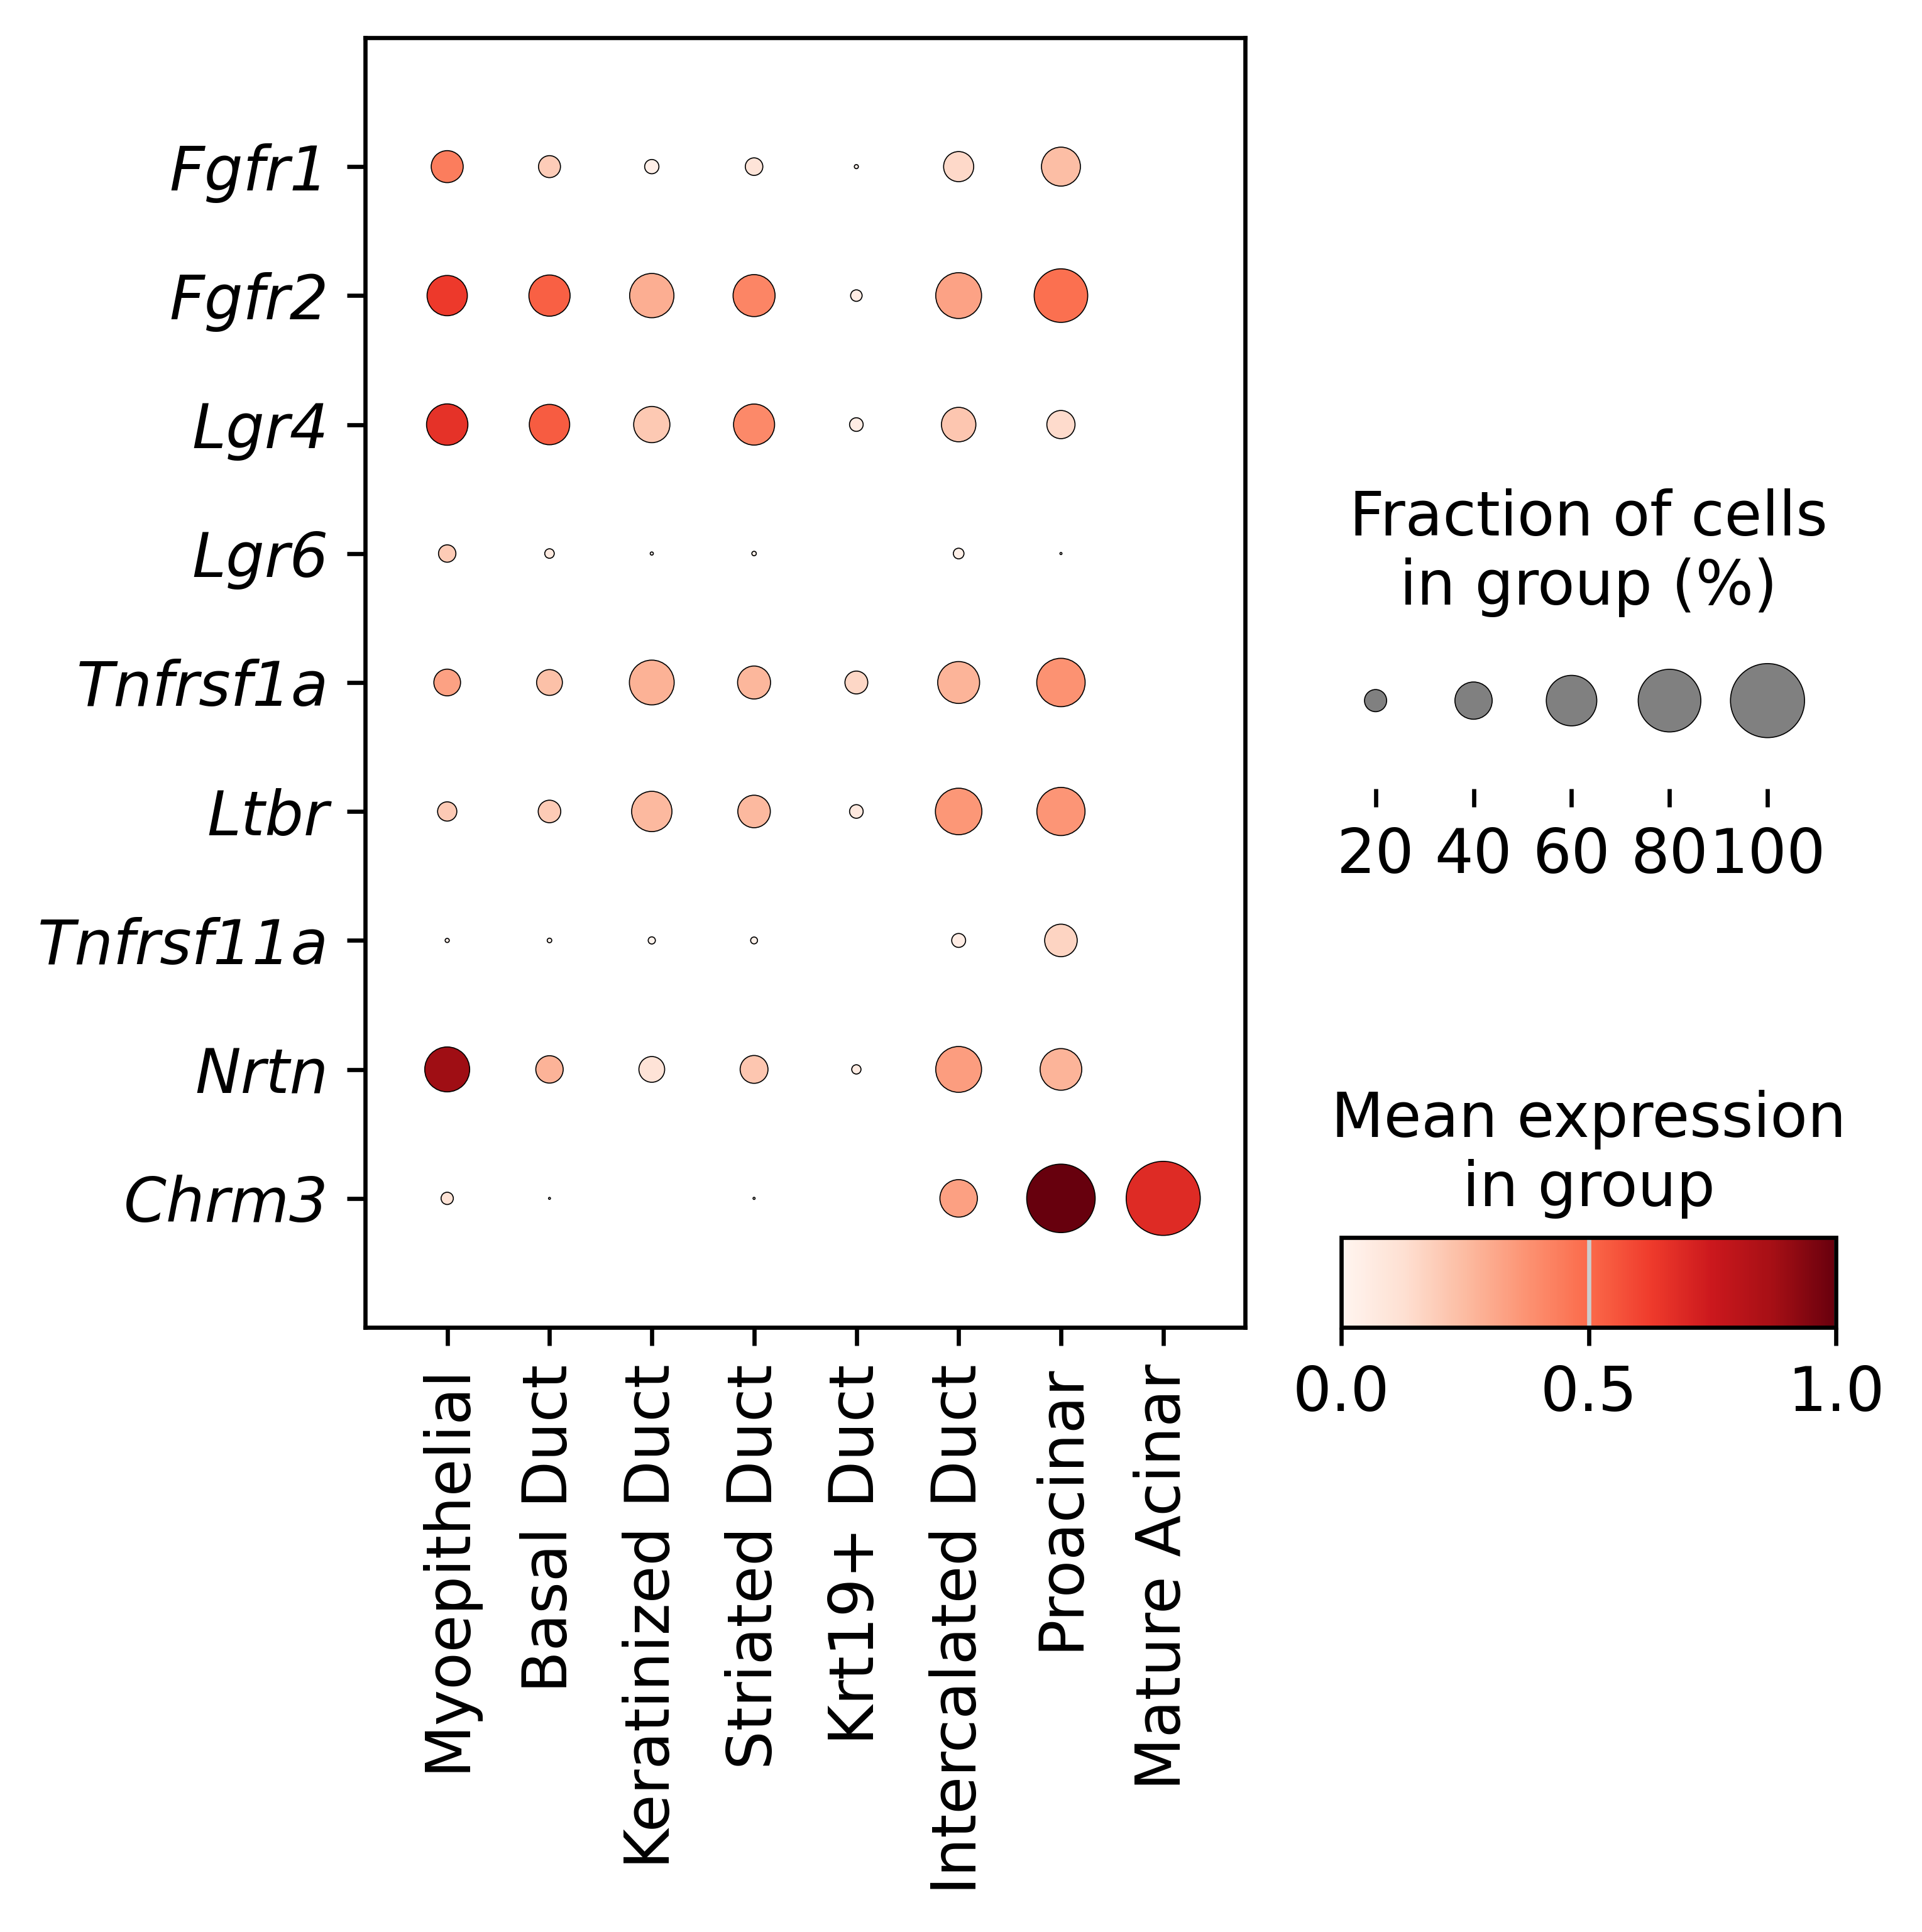

In [70]:
sc.settings.set_figure_params(dpi=300, figsize=(4, 4), color_map='OrRd', frameon=False)

dp = sc.pl.dotplot(adata[~adata.obs['cell_type_v1'].isin(stromalL)], 
                  ['Fgfr1', 'Fgfr2',
                   'Lgr4', 'Lgr6', 
                   'Tnfrsf1a', 'Ltbr', 'Tnfrsf11a', 
                   'Nrtn',
                   'Chrm3'], 
                  groupby='cell_type_v1', 
                  swap_axes=True,
                  vmax=1,
                  figsize=(5,9/2),
                  return_fig=True)

dp = dp.swap_axes().legend(width=1.8).get_axes()

ax=dp['mainplot_ax']
# Loop through ticklabels and make them italic
for l in ax.get_yticklabels():
    l.set_style('italic')
    # g=l.get_text()
    # # Change settings (e.g. color) of certain ticklabels based on their text (here gene name)
    # if g == 'Acta2':
    #     l.set_color('#A97F03')
    # if g in ['Krt5', 'Krt7', 'Krt19', 'Gstt1']:
    #     l.set_color('#A97F03')
    # if g in ['Smgc', 'Bpifa2', 'Aqp5', 'Lpo', 'Bhlha15']:
    #     l.set_color('#A97F03')
        
# ax.figure.savefig('figures/figS1-dotplot-stage.pdf', bbox_inches='tight')

sc.settings.set_figure_params(dpi=100, figsize=(4, 4), color_map='OrRd', frameon=False)

In [72]:
adata = sc.read('write/salivary-fig_240421_3cond-epi-pseudotime.h5ad')

/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


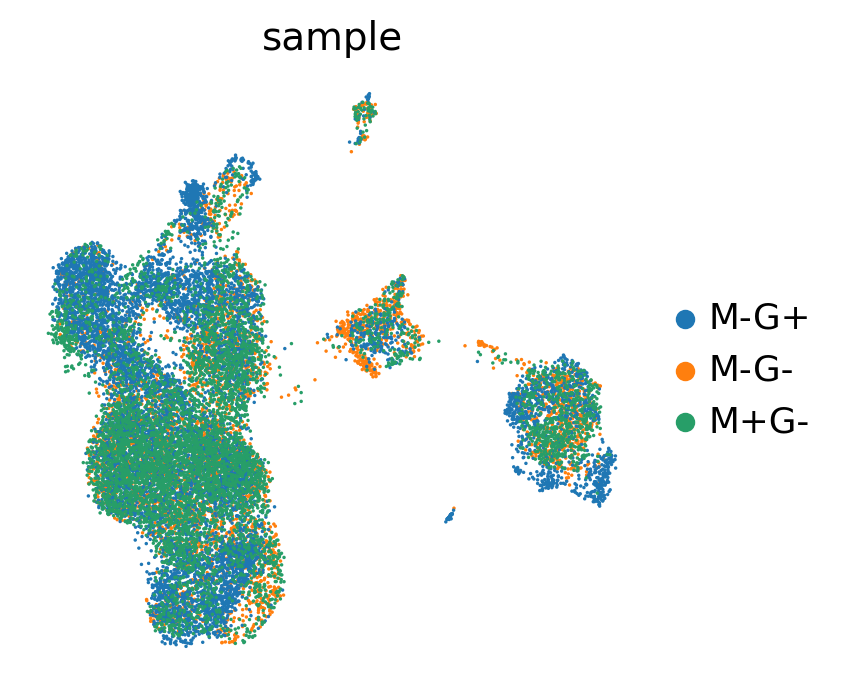

In [73]:
sc.pl.umap(adata, color=['sample'])

/home/yongjunkoh/.conda/envs/rpy2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


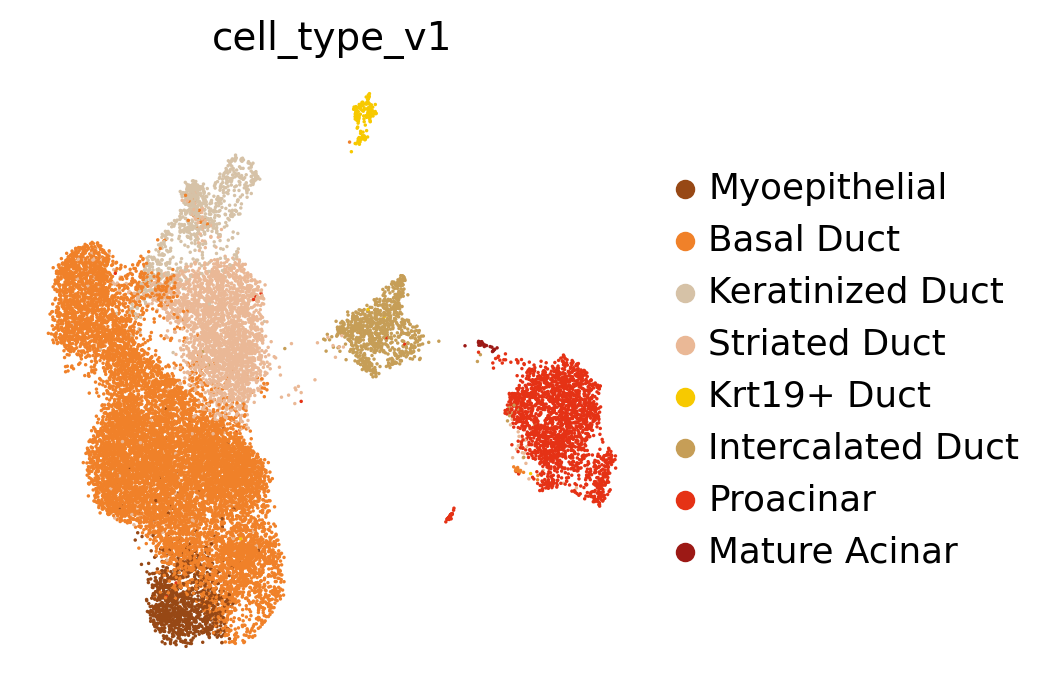

In [74]:
sc.pl.umap(adata, color=['cell_type_v1'])

In [75]:
progeny = dc.get_progeny(organism='human', top=500)
progeny

adata.var.index = [x.upper() for x in adata.var.index]
adata.raw.var.index = [x.upper() for x in adata.raw.var.index]

dc.run_mlm(
    mat=adata,
    net=progeny,
    source='source',
    target='target',
    weight='weight',
    verbose=True
)

adata.obsm['progeny_mlm_estimate'] = adata.obsm['mlm_estimate'].copy()
adata.obsm['progeny_mlm_pvals'] = adata.obsm['mlm_pvals'].copy()
adata

INFO:root:Downloading data from `https://omnipathdb.org/queries/enzsub?format=json`
INFO:root:Downloading data from `https://omnipathdb.org/queries/interactions?format=json`
INFO:root:Downloading data from `https://omnipathdb.org/queries/complexes?format=json`
INFO:root:Downloading data from `https://omnipathdb.org/queries/annotations?format=json`
INFO:root:Downloading data from `https://omnipathdb.org/queries/intercell?format=json`
INFO:root:Downloading data from `https://omnipathdb.org/about?format=text`
INFO:root:Downloading annotations for all proteins from the following resources: `['PROGENy']`


7920 features of mat are empty, they will be removed.
Running mlm on mat with 19374 samples and 24386 targets for 14 sources.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:19<00:00,  9.92s/it]


AnnData object with n_obs × n_vars = 19374 × 32306
    obs: 'latent_RT_efficiency', 'latent_cell_probability', 'latent_scale', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'DouCLing', 'cell_type_v1', 'dpt_pseudotime', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'palantir_pseudotime', 'palantir_entropy', 'Krt19+ Duct', 'Proacinar', 'Keratinized Duct'
    var: 'gene_ids', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_beforecc'
    uns: 'DM_EigenValues', 'DouCLing_colors', 'T_fwd_params', 'cdm_cell_type_v1', 'cdm_leiden_0.5sub', 'cdm_leiden_2.0', 'cell_type_v1_colors', 'coarse_fwd', 'diffmap_evals', 'draw_graph', 'eigendecomposition_fwd', 'hauser20_majority_voting_colors', 'hauser20_predicted_labels_colors', 'hvg', 'iroot', 'leiden

In [76]:
acts = dc.get_acts(adata, obsm_key='mlm_estimate')
acts

AnnData object with n_obs × n_vars = 19374 × 14
    obs: 'latent_RT_efficiency', 'latent_cell_probability', 'latent_scale', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'DouCLing', 'cell_type_v1', 'dpt_pseudotime', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'palantir_pseudotime', 'palantir_entropy', 'Krt19+ Duct', 'Proacinar', 'Keratinized Duct'
    uns: 'DM_EigenValues', 'DouCLing_colors', 'T_fwd_params', 'cdm_cell_type_v1', 'cdm_leiden_0.5sub', 'cdm_leiden_2.0', 'cell_type_v1_colors', 'coarse_fwd', 'diffmap_evals', 'draw_graph', 'eigendecomposition_fwd', 'hauser20_majority_voting_colors', 'hauser20_predicted_labels_colors', 'hvg', 'iroot', 'leiden', 'leiden_0.5_colors', 'leiden_0.5sub_colors', 'leiden_1.0_colors', 'leiden_2.0_colors', 'leiden_30.0_colors', 'log1p', 'macrostates_fwd_co

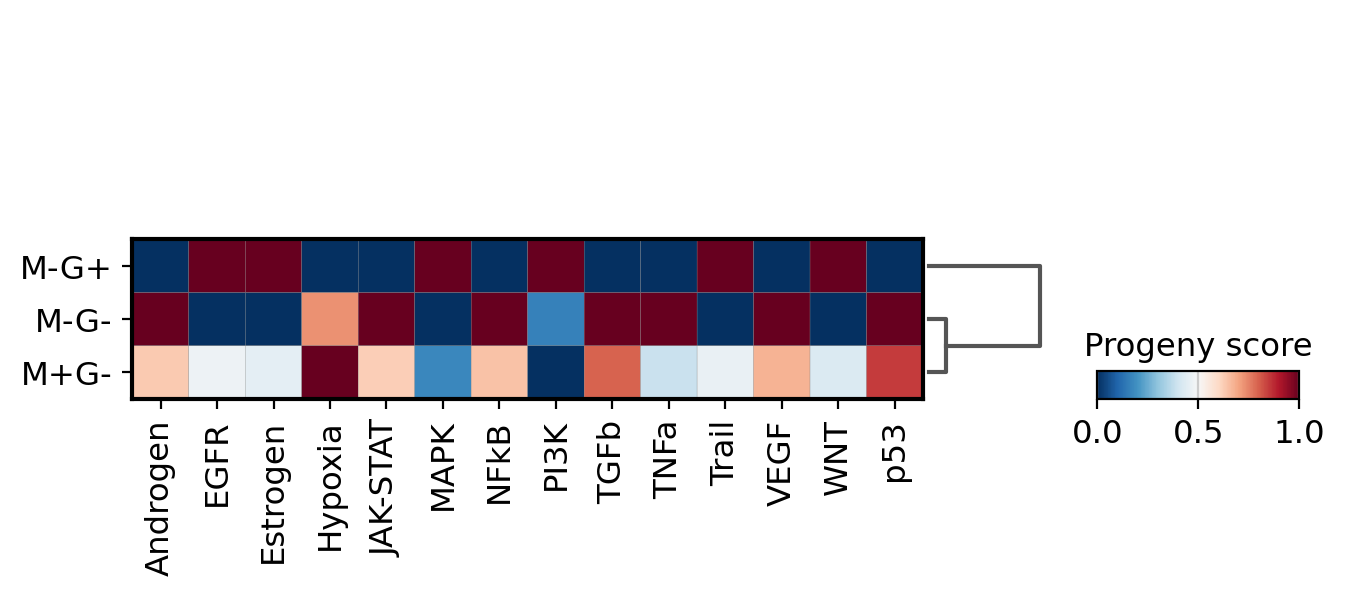

In [80]:
sc.pl.matrixplot(acts, var_names=acts.var_names, groupby='sample', dendrogram=True, standard_scale='var',
                 colorbar_title='Progeny score', cmap='RdBu_r', swap_axes=False)

In [84]:
mean_acts = dc.summarize_acts(acts, groupby='sample', min_std=0)

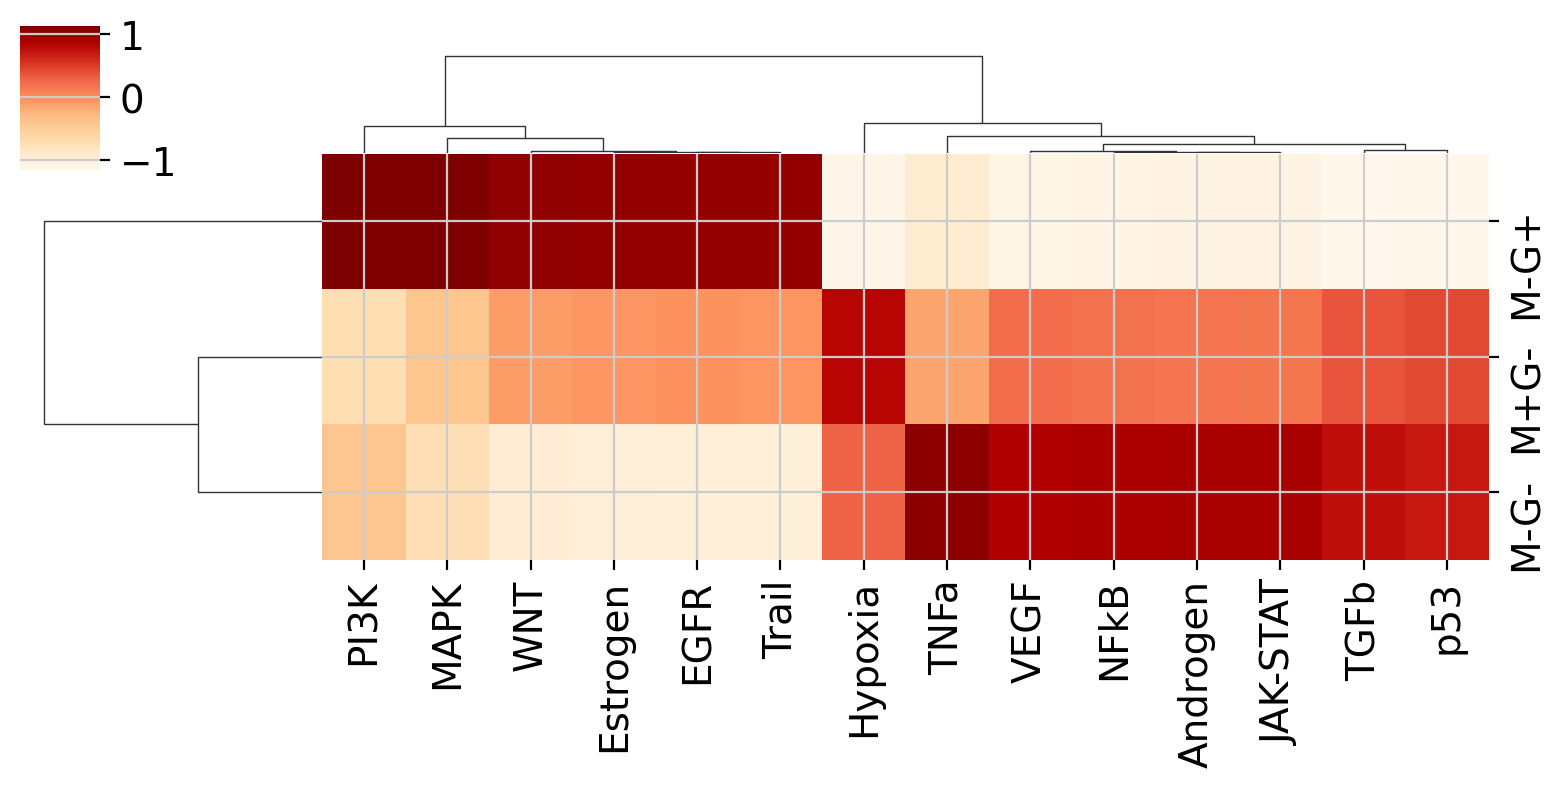

In [108]:
sns.clustermap(mean_acts, xticklabels=mean_acts.columns, z_score=1, cmap='OrRd',figsize=(8, 4))
plt.show()

In [168]:
mean_acts = dc.summarize_acts(acts, groupby='sample', min_std=0)
mean_acts = mean_acts.T[['M-G+', 'M-G-', 'M+G-']].T

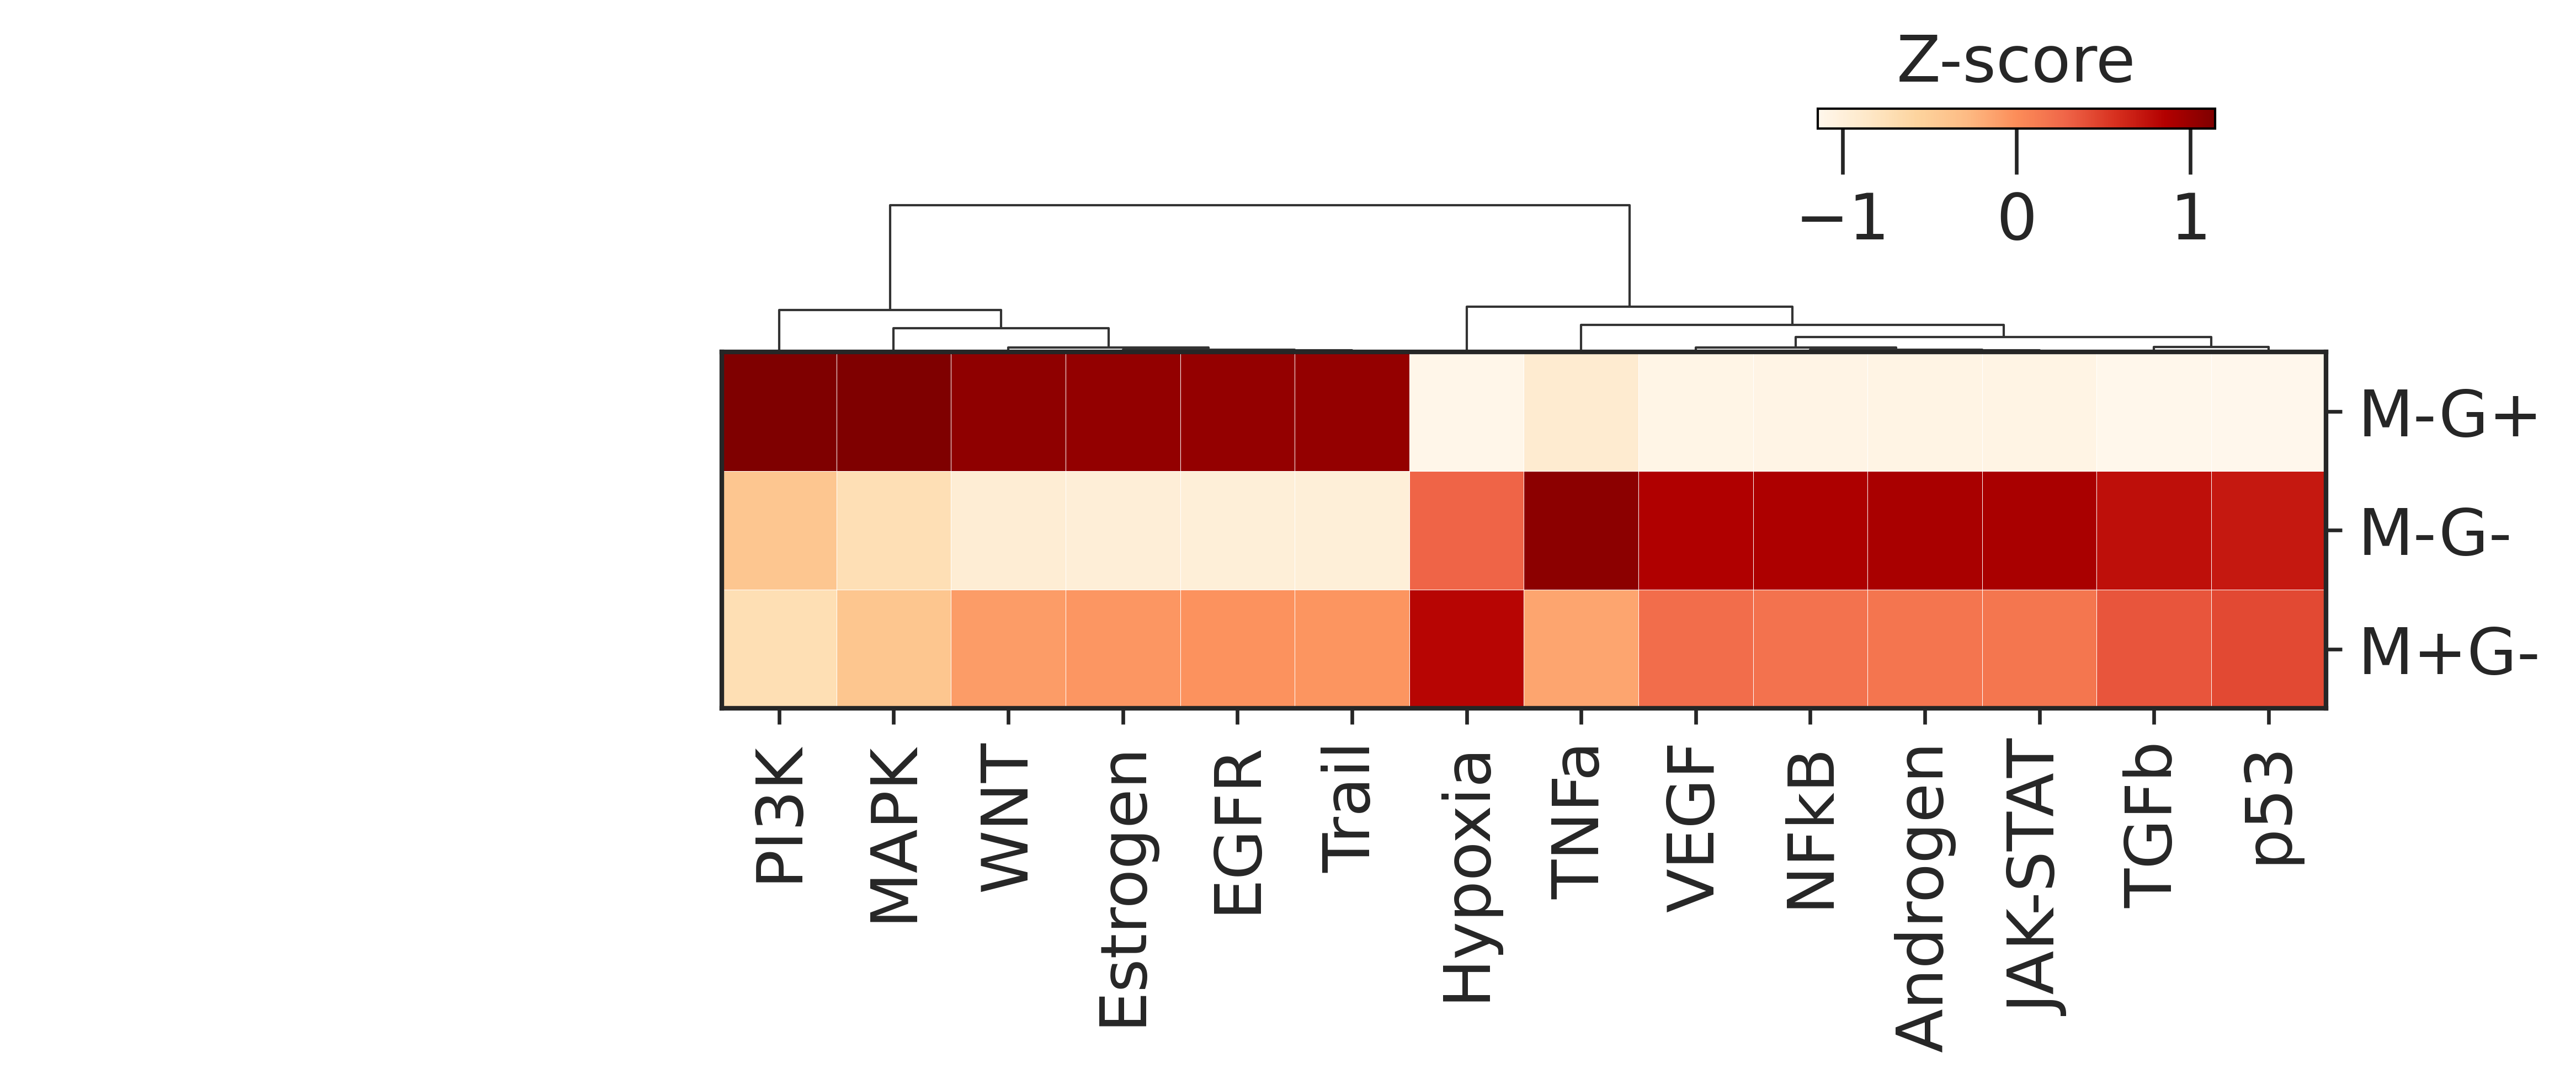

In [183]:
sc.settings.set_figure_params(dpi=300, figsize=(4, 4), color_map='OrRd', frameon=False)

sns.set_style("ticks")

kws = dict(cbar_kws=dict(ticks=[-1, 0, 1], orientation='horizontal'), figsize=(8, 3))

g = sns.clustermap(mean_acts, z_score=1, cmap="OrRd", center=0, dendrogram_ratio=0.3, **kws, linewidth=0.1, row_cluster=False)

x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.7, 1, 0.15, 0.02])
g.ax_cbar.set_title('Z-score')
g.ax_cbar.tick_params(axis='x', length=10)
for spine in g.ax_cbar.spines:
    g.ax_cbar.spines[spine].set_color('black')
    g.ax_cbar.spines[spine].set_linewidth(0.5)
    
for _, spine in g.ax_heatmap.spines.items(): 
    spine.set_visible(True) 
    spine.set_linewidth(1) 

plt.show()

sc.settings.set_figure_params(dpi=100, figsize=(4, 4), color_map='OrRd', frameon=False)

In [187]:
adata.obs['cell_type_v1'].cat.categories

Index(['Myoepithelial', 'Basal Duct', 'Keratinized Duct', 'Striated Duct',
       'Krt19+ Duct', 'Intercalated Duct', 'Proacinar', 'Mature Acinar'],
      dtype='object')

In [190]:
mean_acts = dc.summarize_acts(acts, groupby='cell_type_v1', min_std=0)
mean_acts = mean_acts.T[['Myoepithelial', 'Basal Duct', 'Keratinized Duct', 'Striated Duct',
       'Krt19+ Duct', 'Intercalated Duct', 'Proacinar']].T

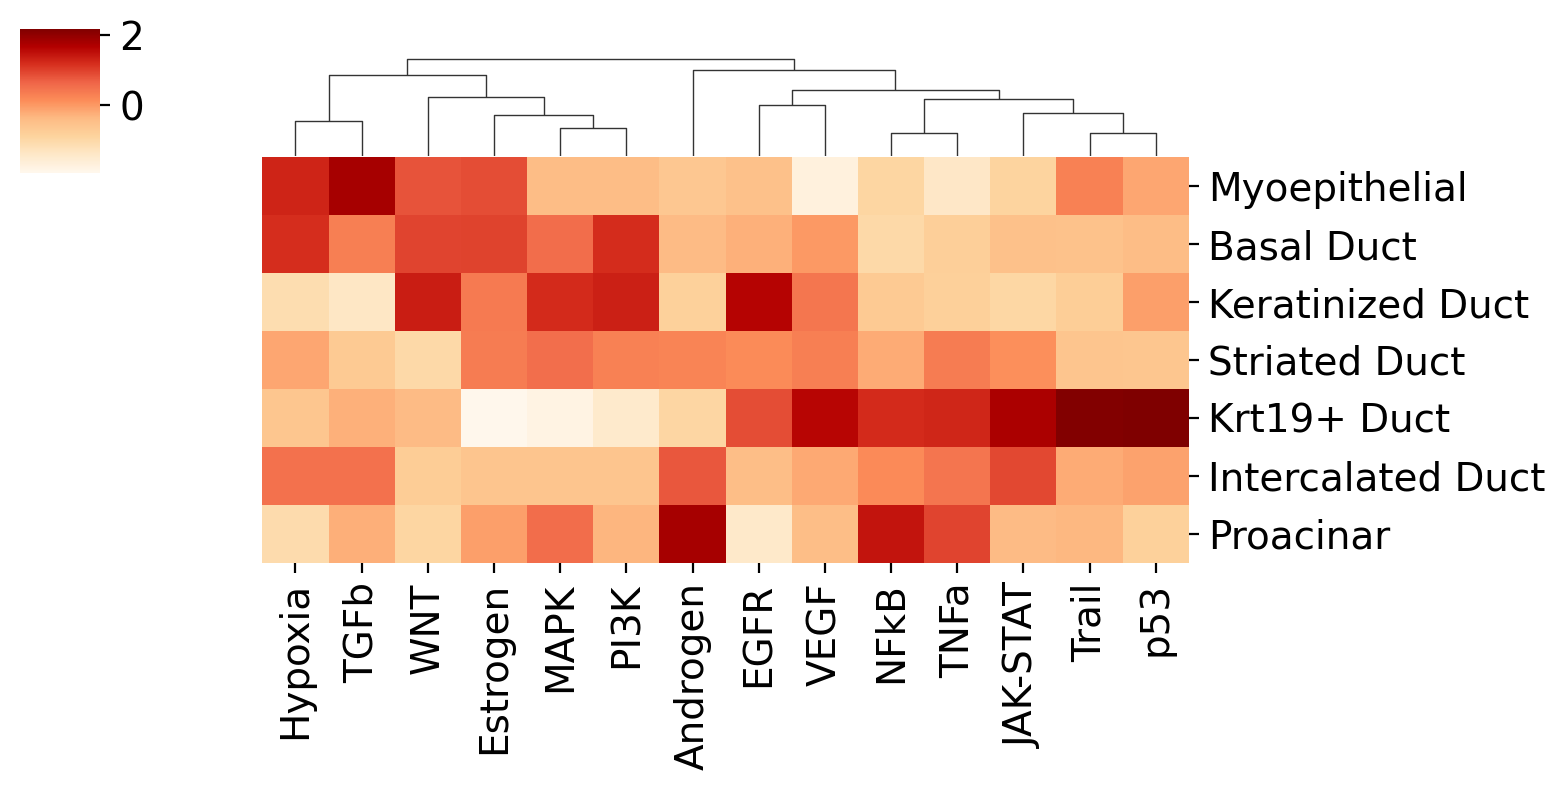

In [191]:
sns.clustermap(mean_acts, xticklabels=mean_acts.columns, z_score=1, cmap='OrRd',figsize=(8, 4), row_cluster=False)
plt.show()

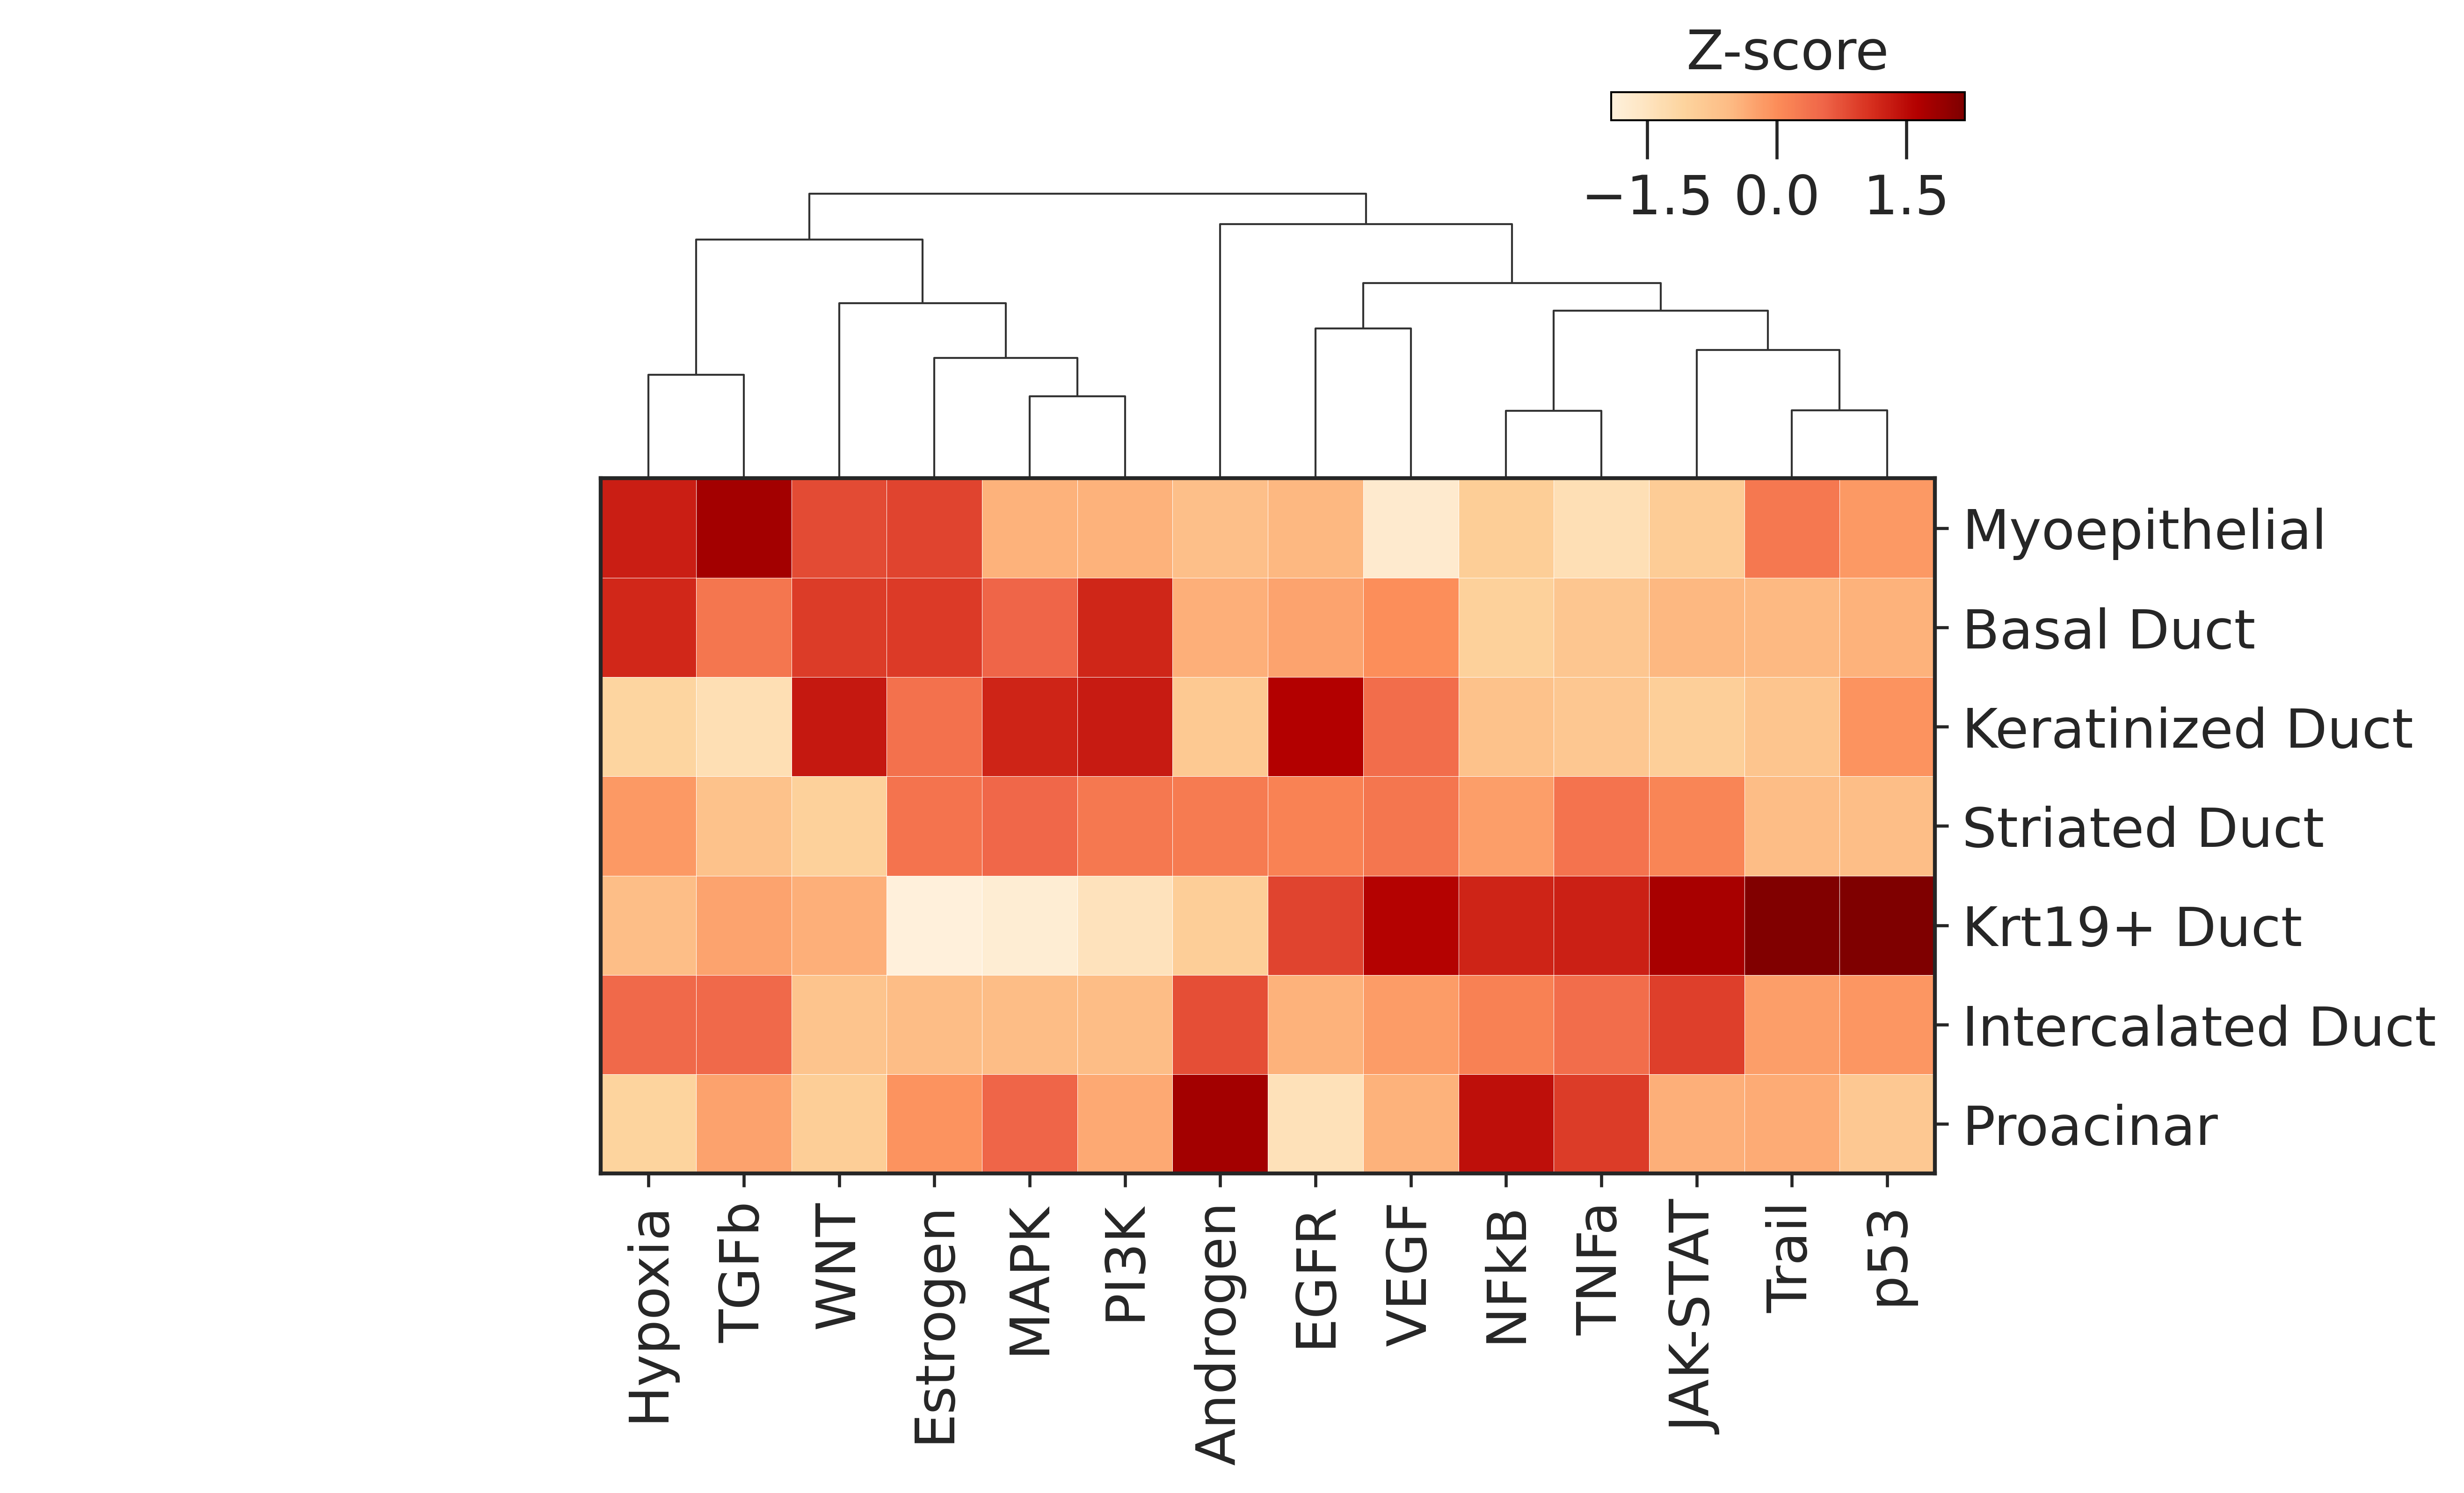

In [204]:
sc.settings.set_figure_params(dpi=300, figsize=(4, 4), color_map='OrRd', frameon=False)

sns.set_style("ticks")

kws = dict(cbar_kws=dict(ticks=[-1.5, 0, 1.5], orientation='horizontal'), figsize=(9, 5))

g = sns.clustermap(mean_acts, z_score=1, cmap="OrRd", center=0, dendrogram_ratio=0.3, **kws, linewidth=0.1, row_cluster=False)

x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.65, 1, 0.14, 0.02])
g.ax_cbar.set_title('Z-score')
g.ax_cbar.tick_params(axis='x', length=10)
for spine in g.ax_cbar.spines:
    g.ax_cbar.spines[spine].set_color('black')
    g.ax_cbar.spines[spine].set_linewidth(0.5)
    
for _, spine in g.ax_heatmap.spines.items(): 
    spine.set_visible(True) 
    spine.set_linewidth(1) 

plt.show()

sc.settings.set_figure_params(dpi=100, figsize=(4, 4), color_map='OrRd', frameon=False)